#### q1, q2 분석 시 사용한 분석 구간

- ACE-ENA G-1의 2017-07-18 자료에서 `Leg_num = 10`을 사용했습니다.
- UTC를 자정 이후 초로 바꾸어 구름 자료와 일대일 결합하여 활용했습니다.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import pearsonr, spearmanr
from IPython.display import display
import figure_npj as npj

DATA_DIR = Path('data')
L, N, DV = 'L (g m-3)', 'N (cm-3)', 'Dv (μm)'
npj.apply_npj()
WIDTH = npj.PAPER_WIDTH_MM / 25.4
COLORS = (npj.HAD_BLUE, npj.OISST_RED, npj.TREND_GRAY)

In [2]:
flight = pd.read_csv(DATA_DIR / 'aaf.iwg1001s.g1.aceena.20170718a.a2.txt',
                     skiprows=[1], na_values=[-9999])
cloud = pd.read_excel(DATA_DIR / 'RF0718_FCDP_cloud.xlsx', usecols='A:D')

flight['Date_Time'] = pd.to_datetime(flight['Date_Time'], utc=True)
utc = flight['Date_Time'].dt
flight['Time'] = utc.hour * 3600 + utc.minute * 60 + utc.second

data = flight.merge(cloud, on='Time', how='inner')
leg10 = data.loc[data['Leg_num'] == 10].sort_values('Time').copy()

## Q1

In [3]:
variables = {
    'Ambient_Temp': 'Temperature (°C)',
    'Vert_Velocity': 'vertical velocity (m/s)',
    'RH_water': 'Relative humidity (%)',
}
values = leg10[list(variables)]
table = pd.DataFrame({
    'n': values.count(), 'mean': values.mean(), 'sd': values.std(ddof=1),
    'median': values.median(), 'IQR': values.quantile(0.75) - values.quantile(0.25),
    'MAD': values.sub(values.median()).abs().median(),
}).rename(index=variables).rename_axis('variable').reset_index()
display(table.round(3))

,variable,n,mean,sd,median,IQR,MAD
0,Temperature (°C),269,13.654,0.104,13.6,0.1,0.1
1,vertical velocity (m/s),269,-0.016,0.553,0.0,0.8,0.4
2,Relative humidity (%),269,105.063,1.130,105.0,1.0,1.0


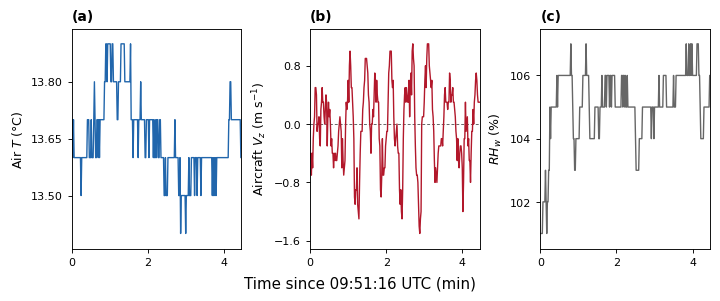

In [4]:
minutes = (leg10['Time'] - leg10['Time'].iloc[0]) / 60
labels = ('Air $T$ (°C)', 'Aircraft $V_z$ (m s$^{-1}$)', '$RH_w$ (%)')
fig, axes = plt.subplots(1, 3, figsize=(WIDTH, 2.9), sharex=True, layout='constrained')
for i, (ax, column, label, color) in enumerate(zip(axes, variables, labels, COLORS)):
    ax.plot(minutes, leg10[column], color=color, lw=1, solid_capstyle='round', zorder=2)
    ax.set(ylabel=label, xlim=(0, minutes.iloc[-1]), xticks=[0, 2, 4])
    ax.set_title(f'({chr(97 + i)})', loc='left', fontsize=10, fontweight='bold')
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.margins(y=0.08)
    npj.closed_frame(ax)
    ax.grid(False)
axes[1].axhline(0, color=npj.TREND_GRAY, lw=0.7, ls=(0, (3, 2)), zorder=1)
start_label = leg10['Date_Time'].iloc[0].strftime('%H:%M:%S')
fig.supxlabel(f'Time since {start_label} UTC (min)')
plt.show()

## Q2

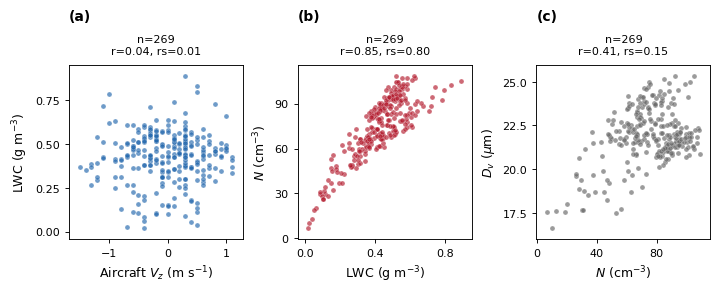

,pair,n,Pearson r,Spearman rs
0,Vert_Velocity ↔ L (g m-3),269,0.038,0.007
1,L (g m-3) ↔ N (cm-3),269,0.847,0.802
2,N (cm-3) ↔ Dv (μm),269,0.409,0.150


In [5]:
pairs = [('Vert_Velocity', L), (L, N), (N, DV)]
axis_labels = {'Vert_Velocity': r'Aircraft $V_z$ (m s$^{-1}$)',
               L: r'LWC (g m$^{-3}$)', N: r'$N$ (cm$^{-3}$)', DV: r'$D_v$ ($\mu$m)'}
results = []
fig, axes = plt.subplots(1, 3, figsize=(WIDTH, 3.1), layout='constrained')
for i, (ax, (xcol, ycol), color) in enumerate(zip(axes, pairs, COLORS)):
    paired = leg10[[xcol, ycol]].dropna()
    r = pearsonr(paired[xcol], paired[ycol]).statistic
    rs = spearmanr(paired[xcol], paired[ycol]).statistic
    ax.scatter(paired[xcol], paired[ycol], s=13, color=color, alpha=0.65,
               edgecolors='white', linewidths=0.25)
    ax.set(xlabel=axis_labels[xcol], ylabel=axis_labels[ycol])
    ax.set_title(f'n={len(paired)}\nr={r:.2f}, rs={rs:.2f}', fontsize=8, pad=8)
    ax.text(0, 1.24, f'({chr(97 + i)})', transform=ax.transAxes,
            ha='left', va='bottom', fontsize=10, fontweight='bold')
    ax.set_box_aspect(1)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.margins(0.07)
    npj.closed_frame(ax)
    ax.grid(False)
    results.append({'pair': f'{xcol} ↔ {ycol}', 'n': len(paired),
                    'Pearson r': r, 'Spearman rs': rs})
plt.show()
correlations = pd.DataFrame(results)
display(correlations.round(3))